# Empirical Evaluation of Prompting, Retrieval-Augmented Generation, and Parameter-Efficient Fine-Tuning for Medical Question Answering

**Course:** COMP5801H - Generative AI and Large Language Models

**Institution:** Carleton University, Winter 2026

**Author:** Dhanshree Kunjalkumar Soni (101384658)

**Project Option:** Option A - Empirical Evaluation

---

## Project Overview

This notebook contains the complete implementation for my course project, which empirically compares three strategies for adapting a large language model to domain-specific medical question answering: prompt engineering, retrieval-augmented generation, and parameter-efficient fine-tuning. All five experimental conditions use Mistral-7B-Instruct-v0.2 as the base model to ensure a fair, controlled comparison. Experiments are conducted on the MedQA (USMLE) benchmark, a publicly available dataset of four-choice questions from the United States Medical Licensing Examination.

The central research question is: under equal compute and data budgets, which adaptation strategy provides the best accuracy-efficiency trade-off for domain-specific medical question answering?

## Notebook Structure

| Section | Content |
|---------|---------|
| Section 1 | Environment Setup and Library Installation |
| Section 2 | Dataset Loading and Preprocessing |
| Section 3 | Loading the Base Model |
| Section 4 | Prompting Baselines — Zero-Shot, Few-Shot, Chain-of-Thought |
| Section 5 | Retrieval-Augmented Generation — FAISS pipeline, ablation k=1,3,5 |
| Section 6 | QLoRA Fine-Tuning |
| Section 7 | Results, Cost Analysis and Error Analysis |
| Section 8 | Conclusion |

## Note on Notebook Structure

This project is documented across two notebooks due to Kaggle's 12-hour session timeout limit. The full experimental pipeline including zero-shot, few-shot, chain-of-thought, RAG, and QLoRA training is in the experiments notebook (Version 1). This notebook contains the QLoRA model evaluation, the complete results analysis in Section 7, and the conclusion in Section 8. All experiment results are loaded from CSV files saved during the experiments run. Both notebooks together constitute the complete project implementation.

# Section 1: Environment Setup

Before anything else, I need to install all the libraries this project depends on. This includes the core transformer and quantization libraries for loading Mistral-7B, the dataset library to pull MedQA from HuggingFace, evaluation libraries for BERTScore and F1, FAISS for the retrieval pipeline, and PEFT/TRL for QLoRA fine-tuning. I am installing everything upfront so there are no interruptions later in the notebook.

In [2]:
# Install all required libraries
!pip install -q transformers accelerate bitsandbytes
!pip install -q datasets evaluate
!pip install -q bert-score rouge-score
!pip install -q faiss-cpu sentence-transformers
!pip install -q peft trl
!pip install -q pandas numpy matplotlib seaborn tqdm
!pip install -q scikit-learn

print("All libraries installed successfully.")

All libraries installed successfully.


In [3]:
!pip install -q -U bitsandbytes>=0.46.1
!pip install -q -U transformers accelerate
import importlib
import bitsandbytes
importlib.reload(bitsandbytes)
print("bitsandbytes updated successfully.")
print("Version:", bitsandbytes.__version__)

bitsandbytes updated successfully.
Version: 0.49.2


# Section 2: Dataset Loading and Preprocessing

In this section I load the MedQA (USMLE) dataset, verify the GPU is available for model inference, and preprocess the data into a clean format that all five experimental conditions will use consistently. I also do a quick inspection of the data structure to make sure everything looks correct before building anything on top of it.

## 2.1 Verifying the GPU Environment

Before loading any models or data, I verify that the GPU is available and check its memory capacity. This matters because Mistral-7B-Instruct requires at least 8GB of VRAM even with 4-bit quantization, so confirming the hardware upfront avoids surprises later.

In [4]:
import torch
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings("ignore")

# Verify GPU
print("=== GPU STATUS ===")
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
print("GPU name:", torch.cuda.get_device_name(0))
print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

=== GPU STATUS ===
CUDA available: True
GPU count: 2
GPU name: Tesla T4
GPU memory: 15.6 GB


## 2.2 Loading the MedQA Dataset

I use the GBaker/MedQA-USMLE-4-options version of MedQA from HuggingFace, which is a clean Parquet-based version of the original dataset containing questions from the United States Medical Licensing Examination. Each question has exactly four answer choices (A, B, C, D) which makes accuracy a clean and unambiguous primary metric.

Note: this dataset does not include a validation split, only train and test. I handle this in the next cell by carving out a validation set from the training data manually.

In [5]:
from datasets import load_dataset

print("Loading MedQA dataset...")
dataset = load_dataset("GBaker/MedQA-USMLE-4-options")

print("\nDataset structure:")
print(dataset)

print("\nTraining samples:", len(dataset['train']))
print("Test samples:", len(dataset['test']))

# Inspect one sample to understand the structure
print("\n=== SAMPLE QUESTION ===")
sample = dataset['train'][0]
for key, value in sample.items():
    print(f"{key}: {value}")

Loading MedQA dataset...

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['question', 'answer', 'options', 'meta_info', 'answer_idx', 'metamap_phrases'],
        num_rows: 10178
    })
    test: Dataset({
        features: ['question', 'answer', 'options', 'meta_info', 'answer_idx', 'metamap_phrases'],
        num_rows: 1273
    })
})

Training samples: 10178
Test samples: 1273

=== SAMPLE QUESTION ===
question: A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels well and is followed by a doctor for her pregnancy. Her temperature is 97.7°F (36.5°C), blood pressure is 122/77 mmHg, pulse is 80/min, respirations are 19/min, and oxygen saturation is 98% on room air. Physical exam is notable for an absence of costovertebral angle tenderness and a gravid uterus. Which of the following is the best tre

## 2.3 Creating the Validation Split

The dataset comes with a train split and a test split but no separate validation split. I carve out 10% of the training data as a validation set using a fixed random seed of 42 to ensure reproducibility. The validation set is what I use to compare all five techniques against each other, keeping the test set untouched for final evaluation.

In [6]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import pandas as pd

# This dataset has train and test only, so we carve out a validation set
# from training data using an 90/10 split — standard practice
train_val = dataset['train'].train_test_split(test_size=0.1, seed=42)

train_data = train_val['train']
val_data   = train_val['test']
test_data  = dataset['test']

print("Split sizes:")
print(f"  Train:      {len(train_data)} samples")
print(f"  Validation: {len(val_data)} samples")
print(f"  Test:       {len(test_data)} samples")

# Inspect one sample to understand the exact structure
print("\n=== SAMPLE QUESTION ===")
sample = train_data[0]
print("Question:", sample['question'])
print("Options:", sample['options'])
print("Answer:", sample['answer'])
print("Answer idx:", sample['answer_idx'])

Split sizes:
  Train:      9160 samples
  Validation: 1018 samples
  Test:       1273 samples

=== SAMPLE QUESTION ===
Question: A 60-year-old man comes to the physician because of flank pain, rash, and blood-tinged urine for 1 day. Two months ago, he was started on hydrochlorothiazide for hypertension. He takes acetaminophen for back pain. Examination shows a generalized, diffuse maculopapular rash. Serum studies show a creatinine concentration of 3.0 mg/dL. Renal ultrasonography shows no abnormalities. Which of the following findings is most likely to be observed in this patient?
Options: {'A': 'Dermal IgA deposition on skin biopsy', 'B': 'Crescent-shape extracapillary cell proliferation', 'C': 'Mesangial IgA deposits on renal biopsy', 'D': 'Urinary eosinophils'}
Answer: Urinary eosinophils
Answer idx: D


## 2.4 Preprocessing into DataFrames

I convert the raw HuggingFace dataset into clean pandas DataFrames with one column per answer option. This consistent structure is used across all five experimental conditions so the formatting logic stays the same throughout the notebook. I also save the three splits as CSV files so they can be reloaded quickly in later sections without re-downloading the dataset.

In [7]:
def build_dataframe(data):
    rows = []
    for item in data:
        options = item['options']
        rows.append({
            'question': item['question'],
            'option_A': options.get('A', ''),
            'option_B': options.get('B', ''),
            'option_C': options.get('C', ''),
            'option_D': options.get('D', ''),
            'answer':   item['answer_idx'],
            'answer_text': item['answer']
        })
    return pd.DataFrame(rows)

train_df = build_dataframe(train_data)
val_df   = build_dataframe(val_data)
test_df  = build_dataframe(test_data)

# Save to CSV so every section of the notebook can reload them
# without re-downloading the dataset
train_df.to_csv('/kaggle/working/train.csv', index=False)
val_df.to_csv('/kaggle/working/val.csv', index=False)
test_df.to_csv('/kaggle/working/test.csv', index=False)

print("DataFrames built and saved.")
print(f"Train:      {len(train_df)} rows")
print(f"Validation: {len(val_df)} rows")
print(f"Test:       {len(test_df)} rows")

print("\n=== PREVIEW (first 2 rows) ===")
train_df.head(2)

DataFrames built and saved.
Train:      9160 rows
Validation: 1018 rows
Test:       1273 rows

=== PREVIEW (first 2 rows) ===


,question,option_A,option_B,option_C,option_D,answer,answer_text
0,A 60-year-old man comes to the physician becau...,Dermal IgA deposition on skin biopsy,Crescent-shape extracapillary cell proliferation,Mesangial IgA deposits on renal biopsy,Urinary eosinophils,D,Urinary eosinophils
1,A 53-year-old male presents to your office for...,Inhibits degradation of endogenous incretins,Inhibits alpha-glucosidases at the intestinal ...,Activates transcription of PPARs to increase p...,Increases secretion of insulin in response to ...,A,Inhibits degradation of endogenous incretins


# Section 3: Loading the Base Model

I use Mistral-7B-Instruct-v0.2 as the base model for all five experimental conditions in this project. Using the same model across every technique is a deliberate design choice, it ensures that any difference in performance is due to the adaptation strategy itself, not the underlying model.

Since a 7B parameter model is too large to fit in GPU memory at full precision, I load it in 4-bit quantization using BitsAndBytes. This reduces the memory footprint from roughly 28GB down to about 6-8GB while keeping performance very close to the full precision version. The quantization settings I use are standard for inference on consumer-grade GPUs.

## 3.1 Loading the Tokenizer and Model

In [ ]:
!pip install -q -U bitsandbytes
import subprocess
result = subprocess.run(['pip', 'show', 'bitsandbytes'], capture_output=True, text=True)
print(result.stdout)

In [12]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch
import time

MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"

# 4-bit quantization config
# nf4 is the recommended quantization type for inference
# double quantization further reduces memory usage
# bfloat16 is used for computation to maintain numerical stability
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"
print("Tokenizer loaded.")

print("\nLoading model in 4-bit quantization (this takes 2-3 minutes)...")
start = time.time()

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)

model.eval()
elapsed = round(time.time() - start, 1)

print(f"\nModel loaded in {elapsed}s")
print(f"Memory footprint: {round(model.get_memory_footprint() / 1e9, 2)} GB")
print(f"Device map: {model.hf_device_map}")

Loading tokenizer...


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]


Model loaded in 62.2s
Memory footprint: 4.01 GB
Device map: {'model.embed_tokens': 0, 'model.layers.0': 0, 'model.layers.1': 0, 'model.layers.2': 0, 'model.layers.3': 0, 'model.layers.4': 0, 'model.layers.5': 0, 'model.layers.6': 0, 'model.layers.7': 0, 'model.layers.8': 0, 'model.layers.9': 0, 'model.layers.10': 0, 'model.layers.11': 0, 'model.layers.12': 1, 'model.layers.13': 1, 'model.layers.14': 1, 'model.layers.15': 1, 'model.layers.16': 1, 'model.layers.17': 1, 'model.layers.18': 1, 'model.layers.19': 1, 'model.layers.20': 1, 'model.layers.21': 1, 'model.layers.22': 1, 'model.layers.23': 1, 'model.layers.24': 1, 'model.layers.25': 1, 'model.layers.26': 1, 'model.layers.27': 1, 'model.layers.28': 1, 'model.layers.29': 1, 'model.layers.30': 1, 'model.layers.31': 1, 'model.norm': 1, 'model.rotary_emb': 1, 'lm_head': 1}


## 3.2 Sanity Check

Before running any experiments, I do a quick sanity check to confirm the model can generate coherent responses to a medical question. I also define the core inference function that all three prompting techniques will use throughout Section 4. The function records inference latency for every call, which feeds directly into the cost analysis in Section 6.

In [13]:
import time

def generate_response(prompt, max_new_tokens=200):
    """
    Core inference function used by all experimental conditions.
    Returns the model response and the time taken in milliseconds.
    """
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to("cuda")

    start = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    latency_ms = round((time.time() - start) * 1000, 1)

    # Decode only the newly generated tokens, not the input prompt
    input_length = inputs['input_ids'].shape[1]
    new_tokens = outputs[0][input_length:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    return response, latency_ms


# Sanity check with a straightforward medical question
test_prompt = """<s>[INST] A 45-year-old patient presents with chest pain radiating to the left arm and diaphoresis. What is the most likely diagnosis?

A) Pneumonia
B) Myocardial infarction
C) Acid reflux
D) Pulmonary embolism

Answer with only the letter of the correct option. [/INST]"""

response, latency = generate_response(test_prompt, max_new_tokens=10)
print(f"Model response: {response}")
print(f"Latency:        {latency} ms")
print("\nSanity check passed." if response.strip().upper().startswith("B") else "\nModel responded but check the output above.")

Model response: B. Myocardial infarction.
Latency:        2590.6 ms

Sanity check passed.


# Section 4: Prompting Baselines

In this section I evaluate three prompting strategies on the validation set. All three use the same Mistral-7B-Instruct model with no modifications to the weights. The only thing that changes between them is how the question is presented to the model.

The three strategies are zero-shot prompting, few-shot prompting, and chain-of-thought prompting. I run all three on a 200-question subset of the validation set using a fixed random seed of 42, and record accuracy, Macro-F1, and inference latency for each. These results form the prompting baseline that RAG and QLoRA are compared against in Section 6.

## 4.1 Zero-Shot Prompting

Zero-shot prompting means asking the model a question directly with no examples or hints about how to answer. This is the simplest possible adaptation strategy and serves as the lowest baseline in the comparison. If a more complex strategy cannot beat zero-shot, it is not worth the added cost.

In [9]:
import re
from tqdm import tqdm

def format_zero_shot(row):
    prompt = f"""<s>[INST] You are a medical expert. Answer the following multiple choice question by choosing the single best answer.

Question: {row['question']}

A) {row['option_A']}
B) {row['option_B']}
C) {row['option_C']}
D) {row['option_D']}

Reply with only the letter of the correct answer (A, B, C, or D) followed by a brief 1-2 sentence justification. [/INST]"""
    return prompt


def extract_answer(response):
    response = response.strip().upper()
    match = re.match(r'^([ABCD])[^A-Z]', response)
    if match:
        return match.group(1)
    match = re.search(r'\b([ABCD])\b', response)
    if match:
        return match.group(1)
    if response and response[0] in 'ABCD':
        return response[0]
    return None


def run_prompting_experiment(df, prompt_formatter, max_new_tokens=150, desc="Running"):
    results = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        prompt = prompt_formatter(row)
        try:
            response, latency = generate_response(prompt, max_new_tokens=max_new_tokens)
            predicted = extract_answer(response)
        except Exception as e:
            response = ""
            latency = 0
            predicted = None
        results.append({
            'question':   row['question'],
            'answer':     row['answer'],
            'predicted':  predicted,
            'correct':    predicted == row['answer'],
            'latency_ms': latency,
            'response':   response
        })
        if (len(results)) % 100 == 0:
            so_far = sum(r['correct'] for r in results)
            print(f"  [{len(results)}/{len(df)}] Running accuracy: {so_far/len(results)*100:.1f}%")
    return pd.DataFrame(results)


print("Core functions defined: format_zero_shot, extract_answer, run_prompting_experiment")

Core functions defined: format_zero_shot, extract_answer, run_prompting_experiment


## 4.2 Zero-Shot Evaluation

I run zero-shot prompting on a 200-question subset sampled from the validation set using a fixed random seed of 42. This same 200-question subset is used across all five experimental conditions to ensure a fair comparison. For each question I record the predicted answer, whether it was correct, and the inference latency. I print a running accuracy update every 100 questions to monitor progress.

In [ ]:
from tqdm import tqdm

# 200 questions is statistically sufficient for comparing techniques
# This is standard practice when working under compute constraints
EVAL_SAMPLE = 200

# Use a fixed seed so the same 200 questions are used across
# all five techniques for a fair comparison
eval_df = val_df.sample(n=EVAL_SAMPLE, random_state=42).reset_index(drop=True)

print(f"Evaluation subset: {len(eval_df)} questions (fixed seed=42)")
print("Running zero-shot experiment...\n")

zero_shot_results = run_prompting_experiment(
    eval_df,
    format_zero_shot,
    max_new_tokens=80,
    desc="Zero-Shot"
)

# Save results immediately
zero_shot_results.to_csv('/kaggle/working/zero_shot_results.csv', index=False)

# Summary
accuracy = zero_shot_results['correct'].mean() * 100
avg_latency = zero_shot_results['latency_ms'].mean()
null_predictions = zero_shot_results['predicted'].isna().sum()

print(f"\n=== ZERO-SHOT RESULTS ===")
print(f"Accuracy:           {accuracy:.2f}%")
print(f"Avg latency:        {avg_latency:.1f} ms")
print(f"Null predictions:   {null_predictions}")
print(f"Total questions:    {len(zero_shot_results)}")

## 4.3 Few-Shot Prompting

Few-shot prompting improves on zero-shot by providing the model with a small number of worked examples before the actual question. The idea is that seeing a few correctly answered questions helps the model understand the expected format and reasoning style. I use 3 examples drawn from the training set, chosen to cover different medical specialties so they are reasonably representative without being too long. The same 3 examples are used for every question in the evaluation set.

In [8]:
# Recreate eval_df from val_df using the same fixed seed used in all experiments
EVAL_SAMPLE = 200
eval_df = val_df.sample(n=EVAL_SAMPLE, random_state=42).reset_index(drop=True)
print(f"eval_df recreated: {len(eval_df)} questions")

eval_df recreated: 200 questions


In [ ]:
# Select 3 fixed few-shot examples from training set
# Using fixed indices so results are reproducible
few_shot_examples = train_df.iloc[[10, 50, 100]]

def format_few_shot(row):
    """
    Formats a MedQA question as a few-shot prompt with 3 examples
    from the training set prepended before the actual question.
    """
    examples_text = ""
    for _, ex in few_shot_examples.iterrows():
        examples_text += f"""Question: {ex['question']}

A) {ex['option_A']}
B) {ex['option_B']}
C) {ex['option_C']}
D) {ex['option_D']}

Answer: {ex['answer']}) {ex['answer_text']}

"""

    prompt = f"""<s>[INST] You are a medical expert. Answer multiple choice questions by choosing the single best answer. Here are some examples of how to answer:

{examples_text}Now answer this question the same way:

Question: {row['question']}

A) {row['option_A']}
B) {row['option_B']}
C) {row['option_C']}
D) {row['option_D']}

Reply with only the letter of the correct answer (A, B, C, or D) followed by a brief 1-2 sentence justification. [/INST]"""
    return prompt


# Test on one example first before running the full set
sample_row = eval_df.iloc[0]
test_prompt = format_few_shot(sample_row)
response, latency = generate_response(test_prompt, max_new_tokens=80)
predicted = extract_answer(response)

print("=== FEW-SHOT TEST ===")
print("Response:", response)
print(f"Extracted: {predicted} | Correct: {sample_row['answer']} | Match: {predicted == sample_row['answer']}")
print(f"Latency: {latency} ms")

## 4.4 Few-Shot Evaluation

I now run few-shot prompting across the same 200-question evaluation subset. The prompt is longer than zero-shot because it includes 3 training examples, which increases inference time per question. This trade-off between prompt length and accuracy is part of what the cost analysis in Section 6 will examine.

In [ ]:
print("Running few-shot experiment on 200-question evaluation subset...")
print("This will take approximately 45-60 minutes due to longer prompts.\n")

few_shot_results = run_prompting_experiment(
    eval_df,
    format_few_shot,
    max_new_tokens=80,
    desc="Few-Shot"
)

# Save results immediately
few_shot_results.to_csv('/kaggle/working/few_shot_results.csv', index=False)

# Summary
accuracy = few_shot_results['correct'].mean() * 100
avg_latency = few_shot_results['latency_ms'].mean()
null_predictions = few_shot_results['predicted'].isna().sum()

print(f"\n=== FEW-SHOT RESULTS ===")
print(f"Accuracy:           {accuracy:.2f}%")
print(f"Avg latency:        {avg_latency:.1f} ms")
print(f"Null predictions:   {null_predictions}")
print(f"Total questions:    {len(few_shot_results)}")
# Verify file was actually saved
import os
size = os.path.getsize('/kaggle/working/few_shot_results.csv')
print(f"File saved successfully: {size} bytes")

## Loading Saved Results

The following cells reload all previously completed experiment results from saved CSV files. Since the full experiments took over 10 hours to run, results are loaded from saved outputs rather than rerunning the experiments in this notebook.

In [23]:
import pandas as pd
import os

# Kaggle persistent storage — files here survive session restarts
SAVE_DIR = '/kaggle/working'

results_store = {}

files = {
    'zero_shot':  '/kaggle/working/zero_shot_results.csv',
    'few_shot':   '/kaggle/working/few_shot_results.csv',
    'cot':        '/kaggle/working/cot_results.csv',
    'rag_k1':     '/kaggle/working/rag_k1_results.csv',
    'rag_k3':     '/kaggle/working/rag_k3_results.csv',
    'rag_k5':     '/kaggle/working/rag_k5_results.csv',
    'qlora':      '/kaggle/working/qlora_results.csv',
}

for name, fname in files.items():
    fpath = os.path.join(SAVE_DIR, fname)
    if os.path.exists(fpath):
        results_store[name] = pd.read_csv(fpath)
        acc = results_store[name]['correct'].mean() * 100
        print(f"Loaded {name}: {len(results_store[name])} rows | Accuracy: {acc:.2f}%")
    else:
        print(f"Not yet available: {name}")

Loaded zero_shot: 200 rows | Accuracy: 35.50%
Loaded few_shot: 200 rows | Accuracy: 32.00%
Loaded cot: 200 rows | Accuracy: 32.50%
Loaded rag_k1: 200 rows | Accuracy: 38.00%
Loaded rag_k3: 200 rows | Accuracy: 34.00%
Loaded rag_k5: 200 rows | Accuracy: 33.50%
Loaded qlora: 200 rows | Accuracy: 40.00%


## 4.5 Chain-of-Thought Prompting

Chain-of-thought prompting asks the model to reason through a problem step by step before giving a final answer. The idea is that medical questions often require multi-step clinical reasoning, ruling out conditions, recalling drug mechanisms, connecting symptoms to diagnoses and forcing the model to write that reasoning out loud before committing to an answer tends to improve accuracy. I add a explicit instruction to think step by step and then state the final answer as the last line of the response.

In [ ]:
def format_cot(row):
    """
    Formats a MedQA question as a chain-of-thought prompt.
    The model is explicitly asked to reason step by step before
    giving a final answer letter on the last line.
    """
    prompt = f"""<s>[INST] You are a medical expert. Answer the following multiple choice question by reasoning step by step.

Question: {row['question']}

A) {row['option_A']}
B) {row['option_B']}
C) {row['option_C']}
D) {row['option_D']}

Think through this step by step, then on the very last line write only: Answer: X where X is the letter of the correct option. [/INST]"""
    return prompt


def extract_cot_answer(response):
    """
    Extracts the final answer from a chain-of-thought response.
    Looks for 'Answer: X' pattern first, then falls back to
    the standard extract_answer function.
    """
    # Look for explicit Answer: X pattern at end of response
    match = re.search(r'Answer:\s*([ABCD])', response.upper())
    if match:
        return match.group(1)

    # Fallback to standard extractor
    return extract_answer(response)


# Test on one example before running full set
sample_row = eval_df.iloc[0]
test_prompt = format_cot(sample_row)
response, latency = generate_response(test_prompt, max_new_tokens=300)
predicted = extract_cot_answer(response)

print("=== COT TEST ===")
print("Response:", response)
print(f"\nExtracted: {predicted} | Correct: {sample_row['answer']} | Match: {predicted == sample_row['answer']}")
print(f"Latency: {latency} ms")

## 4.6 Chain-of-Thought Evaluation

I now run chain-of-thought prompting across the same 200-question evaluation subset. CoT prompts generate longer responses than zero-shot or few-shot because the model writes out its reasoning before giving a final answer. This increases latency per question but the hypothesis is that the reasoning process improves accuracy on questions that require multi-step clinical logic.

In [ ]:
print("Running chain-of-thought experiment on 200-question evaluation subset...")
print("This will take approximately 50-65 minutes due to longer responses.\n")

cot_results = run_prompting_experiment(
    eval_df,
    format_cot,
    max_new_tokens=300,
    desc="CoT"
)

# Save results immediately
cot_results.to_csv('/kaggle/working/cot_results.csv', index=False)

# Summary
accuracy = cot_results['correct'].mean() * 100
avg_latency = cot_results['latency_ms'].mean()
null_predictions = cot_results['predicted'].isna().sum()

print(f"\n=== CHAIN-OF-THOUGHT RESULTS ===")
print(f"Accuracy:           {accuracy:.2f}%")
print(f"Avg latency:        {avg_latency:.1f} ms")
print(f"Null predictions:   {null_predictions}")
print(f"Total questions:    {len(cot_results)}")

# Section 5: Retrieval-Augmented Generation (RAG)

The prompting results showed that zero-shot, few-shot, and chain-of-thought prompting all perform in the range of 32-38% accuracy on MedQA, with zero-shot being the strongest prompting baseline at 36.60%. This makes sense, Mistral-7B-Instruct is a general-purpose model and does not have deep enough medical knowledge encoded in its weights to reliably answer USMLE-level questions through prompting alone.

Retrieval-Augmented Generation addresses this by giving the model access to relevant information at inference time. Instead of relying purely on what the model already knows, RAG retrieves the most relevant passages from a document corpus and includes them in the prompt as context before asking the model to answer. The model can then ground its response in retrieved evidence rather than recalled knowledge.

My RAG pipeline works in two stages. First I build a FAISS vector database from the MedQA training set by encoding every training question and answer into dense vector embeddings. At inference time, for each validation question I retrieve the top-k most similar training examples and prepend them as context to the prompt. I then run this experiment with k set to 1, 3, and 5 to study how retrieval depth affects accuracy and latency — this is the ablation study described in my project proposal.

## 5.1 Building the FAISS Vector Database

In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import time

# Load the sentence transformer model for generating embeddings
# all-MiniLM-L6-v2 is lightweight, fast, and works well for semantic similarity
print("Loading sentence transformer model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print("Embedder loaded.")

# Build corpus from training set
# Each entry combines the question with its correct answer
# so retrieved examples are informative for the validation question
print("\nBuilding corpus from training set...")
corpus = []
for _, row in train_df.iterrows():
    entry = f"Question: {row['question']} Answer: {row['answer']} - {row['answer_text']}"
    corpus.append(entry)

print(f"Corpus size: {len(corpus)} entries")

# Generate embeddings for the full training corpus
print("\nGenerating embeddings (this takes 3-5 minutes)...")
start = time.time()
corpus_embeddings = embedder.encode(
    corpus,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
elapsed = round(time.time() - start, 1)
print(f"Embeddings generated in {elapsed}s")
print(f"Embedding shape: {corpus_embeddings.shape}")

# Build FAISS index
# IndexFlatIP uses inner product similarity — equivalent to cosine
# similarity when vectors are normalized
print("\nBuilding FAISS index...")
faiss.normalize_L2(corpus_embeddings)
dimension = corpus_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(corpus_embeddings)
print(f"FAISS index built with {index.ntotal} vectors")
print(f"Vector dimension: {dimension}")

# Record indexing time for cost analysis
indexing_time = elapsed
print(f"\nTotal indexing time: {indexing_time}s")

## 5.2 RAG Retrieval and Prompt Formatting

With the FAISS index built, I now define the retrieval function and the RAG prompt formatter. For each validation question, I encode it into the same embedding space, query the FAISS index for the top-k most similar training examples, and prepend those examples as context to the prompt. I then run three separate experiments with k set to 1, 3, and 5 to measure how retrieval depth affects both accuracy and latency.

In [ ]:
def retrieve_similar(question, k=3):
    """
    Retrieves the top-k most similar training examples
    for a given question using FAISS cosine similarity search.
    Returns a list of (question, answer) tuples.
    """
    query_embedding = embedder.encode([question], convert_to_numpy=True)
    faiss.normalize_L2(query_embedding)
    distances, indices = index.search(query_embedding, k)

    retrieved = []
    for idx in indices[0]:
        row = train_df.iloc[idx]
        retrieved.append({
            'question':     row['question'],
            'option_A':     row['option_A'],
            'option_B':     row['option_B'],
            'option_C':     row['option_C'],
            'option_D':     row['option_D'],
            'answer':       row['answer'],
            'answer_text':  row['answer_text']
        })
    return retrieved


def format_rag(row, k=3):
    """
    Formats a MedQA question as a RAG prompt with k retrieved
    training examples prepended as context.
    """
    retrieved = retrieve_similar(row['question'], k=k)

    context = ""
    for i, ex in enumerate(retrieved):
        context += f"""Example {i+1}:
Question: {ex['question']}
A) {ex['option_A']}
B) {ex['option_B']}
C) {ex['option_C']}
D) {ex['option_D']}
Answer: {ex['answer']}) {ex['answer_text']}

"""

    prompt = f"""<s>[INST] You are a medical expert. Use the following similar examples as context to help answer the question below.

{context}Now answer this question:

Question: {row['question']}

A) {row['option_A']}
B) {row['option_B']}
C) {row['option_C']}
D) {row['option_D']}

Reply with only the letter of the correct answer (A, B, C, or D) followed by a brief 1-2 sentence justification. [/INST]"""
    return prompt


# Test retrieval on one example
sample_row = eval_df.iloc[0]

print("=== RETRIEVAL TEST (k=3) ===")
retrieved = retrieve_similar(sample_row['question'], k=3)
print(f"Query: {sample_row['question'][:100]}...")
print(f"\nRetrieved {len(retrieved)} examples:")
for i, r in enumerate(retrieved):
    print(f"  [{i+1}] {r['question'][:80]}... -> {r['answer']}")

# Test full RAG prompt on one example
response, latency = generate_response(
    format_rag(sample_row, k=3),
    max_new_tokens=100
)
predicted = extract_answer(response)

print(f"\n=== RAG RESPONSE (k=3) ===")
print("Response:", response)
print(f"\nExtracted: {predicted} | Correct: {sample_row['answer']} | Match: {predicted == sample_row['answer']}")
print(f"Latency: {latency} ms")

## 5.3 RAG Experiments: Ablation over k

I run three separate RAG experiments using k=1, k=3, and k=5 retrieved examples. This ablation study measures how retrieval depth affects both accuracy and inference latency. A higher k gives the model more context but also makes the prompt longer and slower. The goal is to find whether more retrieved examples actually help or whether they add noise that hurts performance.

In [ ]:
import functools

for k in [1, 3, 5]:
    print(f"\nRunning RAG experiment with k={k}...")
    print(f"Estimated time: {'20-25' if k==1 else '30-40' if k==3 else '40-50'} minutes\n")

    # Create a prompt formatter with k fixed using functools.partial
    rag_formatter = functools.partial(format_rag, k=k)

    rag_results = run_prompting_experiment(
        eval_df,
        rag_formatter,
        max_new_tokens=100,
        desc=f"RAG k={k}"
    )

    # Save immediately after each k
    rag_results.to_csv(f'/kaggle/working/rag_k{k}_results.csv', index=False)

    accuracy = rag_results['correct'].mean() * 100
    avg_latency = rag_results['latency_ms'].mean()
    null_predictions = rag_results['predicted'].isna().sum()

    print(f"\n=== RAG k={k} RESULTS ===")
    print(f"Accuracy:         {accuracy:.2f}%")
    print(f"Avg latency:      {avg_latency:.1f} ms")
    print(f"Null predictions: {null_predictions}")
    print(f"Total questions:  {len(rag_results)}")
    print("-" * 40)

print("\nAll RAG experiments complete.")

# Section 6: QLoRA Fine-Tuning

The prompting and RAG experiments established a ceiling of around 38% accuracy using inference-only adaptation strategies. To go beyond this, the model needs to actually learn from the medical training data rather than just retrieving or being shown examples at inference time.

QLoRA (Quantized Low-Rank Adaptation) makes this feasible under limited compute. Instead of updating all 7 billion parameters of Mistral-7B, QLoRA keeps the base model frozen in 4-bit quantization and trains a small set of low-rank adapter matrices that are injected into the attention layers. The number of trainable parameters is a tiny fraction of the full model, which means training fits comfortably within the GPU memory available on Kaggle.

I fine-tune on the MedQA training set by formatting each training example as an instruction-following prompt with the correct answer and a brief justification. After training I merge the LoRA adapters back into the base model and evaluate on the same 200-question evaluation subset used by all other techniques.

## 6.1 Fine-Tuning Setup

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from transformers import TrainingArguments
from trl import SFTTrainer
import torch

# Prepare model for QLoRA training
# This adds gradient checkpointing and prepares the quantized
# model to accept trainable LoRA adapter layers
print("Preparing model for QLoRA training...")
model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

# LoRA configuration
# r=16 is the rank of the adapter matrices — higher rank means
# more parameters but better expressiveness
# target_modules specifies which layers get LoRA adapters
# alpha=32 is the scaling factor for the adapter outputs
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

# Apply LoRA adapters to the model
model = get_peft_model(model, lora_config)

# Print trainable parameter count to confirm QLoRA is working
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable %:          {100 * trainable_params / total_params:.4f}%")

## 6.2 Preparing the Training Data

I format each training example as an instruction, following prompt that matches the same format used during inference. Each example includes the question, the four answer options, and the correct answer with a brief explanation. This consistency between training and inference format is important, the model learns to produce outputs in exactly the style we evaluate it on.

In [ ]:
from datasets import Dataset

def format_training_example(row):
    """
    Formats a training example as a complete instruction-response
    pair for supervised fine-tuning. The model learns to map
    the question prompt to the correct answer and justification.
    """
    prompt = f"""<s>[INST] You are a medical expert. Answer the following multiple choice question by choosing the single best answer.

Question: {row['question']}

A) {row['option_A']}
B) {row['option_B']}
C) {row['option_C']}
D) {row['option_D']}

Reply with only the letter of the correct answer (A, B, C, or D) followed by a brief 1-2 sentence justification. [/INST]"""

    response = f" {row['answer']}) {row['answer_text']}</s>"

    return prompt + response


# Format all training examples
print("Formatting training examples...")
formatted_examples = [format_training_example(row) for _, row in train_df.iterrows()]

print(f"Total training examples: {len(formatted_examples)}")
print(f"\n=== SAMPLE FORMATTED EXAMPLE ===")
print(formatted_examples[0])

# Convert to HuggingFace Dataset format required by SFTTrainer
train_dataset = Dataset.from_dict({"text": formatted_examples})
print(f"\nTraining dataset created: {len(train_dataset)} examples")

## 6.3 Training

I train the LoRA adapters using the SFTTrainer from the TRL library. Due to compute constraints on Kaggle's free GPU tier, I train for 1 epoch on a 2000-example subset of the training data. The learning rate is set to 2e-4 which is the standard recommended value for QLoRA fine-tuning. I use gradient accumulation to simulate a larger effective batch size without increasing memory usage. The training loss decreased steadily from 1.33 to 0.89 over 125 steps, confirming the model was learning from the medical training data.

In [ ]:
import time
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

# Using 2000 examples for 1 epoch to keep training time manageable
# This is sufficient to demonstrate domain adaptation for comparison purposes
sample_df = train_df.sample(n=2000, random_state=42).reset_index(drop=True)
formatted_sample = [format_training_example(row) for _, row in sample_df.iterrows()]
train_dataset_small = Dataset.from_dict({"text": formatted_sample})

print(f"Training on {len(train_dataset_small)} examples for 1 epoch")

training_args = SFTConfig(
    output_dir="./qlora_output",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    bf16=True,
    fp16=False,
    logging_steps=25,
    save_strategy="no",
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    warmup_steps=20,
    report_to="none",
    dataloader_num_workers=0,
    max_length=512,
    dataset_text_field="text",
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_small,
    processing_class=tokenizer,
)

print("Starting QLoRA training (1 epoch, 2000 examples)...")
print("Expected time: 45-60 minutes\n")

training_start = time.time()
trainer.train()
training_time = round(time.time() - training_start, 1)

print(f"\nTraining complete.")
print(f"Total training time: {training_time}s ({round(training_time/60, 1)} minutes)")

print(f"\nSaving trained model...")
trainer.save_model("./qlora_trained")
tokenizer.save_pretrained("./qlora_trained")
print("Model saved to ./qlora_trained")

In [16]:
import shutil
import os

# Find the uploaded dataset path
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv') and 'results' in f:
            src = os.path.join(root, f)
            dst = f'/kaggle/working/{f}'
            shutil.copy(src, dst)
            print(f"Copied: {f}")

print("\nDone.")

Copied: rag_k3_results.csv
Copied: zero_shot_results.csv
Copied: rag_k1_results.csv
Copied: cot_results.csv
Copied: few_shot_results.csv
Copied: rag_k5_results.csv

Done.


In [17]:
import shutil
import os

# Copy all results to /kaggle/working which persists after session ends
files_to_save = [
    'zero_shot_results.csv',
    'few_shot_results.csv', 
    'cot_results.csv',
    'rag_k1_results.csv',
    'rag_k3_results.csv',
    'rag_k5_results.csv',
    'qlora_results.csv',
]

print("Verifying saved files:")
for f in files_to_save:
    path = f'/kaggle/working/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path)
        print(f"  {f}: {size} bytes")
    else:
        print(f"  {f}: NOT FOUND")

Verifying saved files:
  zero_shot_results.csv: 201034 bytes
  few_shot_results.csv: 191942 bytes
  cot_results.csv: 332166 bytes
  rag_k1_results.csv: 209736 bytes
  rag_k3_results.csv: 205889 bytes
  rag_k5_results.csv: 205372 bytes
  qlora_results.csv: NOT FOUND


## 6.4 Evaluating the Fine-Tuned Model

With the LoRA adapters trained and saved, I now evaluate the fine-tuned model on the same 200-question evaluation subset used by all other techniques. I load the trained adapters back onto the base model and run inference using the same zero-shot prompt format so the comparison is fair.

In [20]:
import shutil
import os

src = '/kaggle/input/datasets/dhanshreesoni09/qlora-trained'
dst = './qlora_trained'

if os.path.exists(dst):
    shutil.rmtree(dst)

shutil.copytree(src, dst)
print("qlora_trained copied successfully.")
print("Contents:", os.listdir('./qlora_trained'))

qlora_trained copied successfully.
Contents: ['adapter_model.safetensors', 'training_args.bin', 'README.md', 'tokenizer.json', 'adapter_config.json', 'tokenizer_config.json', 'chat_template.jinja']


In [21]:
from peft import PeftModel
from tqdm import tqdm
import time

print("Loading fine-tuned model for evaluation...")
ft_model = PeftModel.from_pretrained(model, "./qlora_trained")
ft_model.eval()
print("Fine-tuned model loaded.\n")

print("Running QLoRA evaluation on 200-question subset...")
qlora_rows = []

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="QLoRA Eval"):
    prompt = format_zero_shot(row)
    try:
        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=2048
        ).to("cuda")

        start = time.time()
        with torch.no_grad():
            outputs = ft_model.generate(
                **inputs,
                max_new_tokens=80,
                do_sample=False,
                temperature=1.0,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
        latency_ms = round((time.time() - start) * 1000, 1)

        input_length = inputs['input_ids'].shape[1]
        new_tokens = outputs[0][input_length:]
        response = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
        predicted = extract_answer(response)

    except Exception as e:
        response = ""
        latency_ms = 0
        predicted = None

    qlora_rows.append({
        'question':   row['question'],
        'answer':     row['answer'],
        'predicted':  predicted,
        'correct':    predicted == row['answer'],
        'latency_ms': latency_ms,
        'response':   response
    })

    if len(qlora_rows) % 100 == 0:
        so_far = sum(r['correct'] for r in qlora_rows)
        print(f"  [{len(qlora_rows)}/200] Running accuracy: {so_far/len(qlora_rows)*100:.1f}%")

qlora_results = pd.DataFrame(qlora_rows)
qlora_results.to_csv('/kaggle/working/qlora_results.csv', index=False)

accuracy = qlora_results['correct'].mean() * 100
avg_latency = qlora_results['latency_ms'].mean()
null_predictions = qlora_results['predicted'].isna().sum()

print(f"\n=== QLORA RESULTS ===")
print(f"Accuracy:           {accuracy:.2f}%")
print(f"Avg latency:        {avg_latency:.1f} ms")
print(f"Null predictions:   {null_predictions}")
print(f"Total questions:    {len(qlora_results)}")

Loading fine-tuned model for evaluation...
Fine-tuned model loaded.

Running QLoRA evaluation on 200-question subset...


QLoRA Eval:  50%|█████     | 100/200 [06:00<06:51,  4.12s/it]

  [100/200] Running accuracy: 39.0%


QLoRA Eval: 100%|██████████| 200/200 [12:23<00:00,  3.72s/it]

  [200/200] Running accuracy: 40.0%

=== QLORA RESULTS ===
Accuracy:           40.00%
Avg latency:        3716.3 ms
Null predictions:   0
Total questions:    200


# Section 7: Results and Analysis

This section brings together all experimental results and analyzes the findings across all five adaptation strategies. I organize the analysis into five parts: a full metrics comparison covering accuracy and Macro-F1, BERTScore on generated reasoning, a cost analysis examining setup overhead against inference latency, visualizations of the key comparisons, a discussion of what the results mean, and an error analysis that categorizes failure modes into fact retrieval failures and clinical reasoning failures.

In [24]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import matplotlib
import os

# Load all 7 results
results = {
    'Zero-Shot':  pd.read_csv('/kaggle/working/zero_shot_results.csv'),
    'Few-Shot':   pd.read_csv('/kaggle/working/few_shot_results.csv'),
    'CoT':        pd.read_csv('/kaggle/working/cot_results.csv'),
    'RAG k=1':    pd.read_csv('/kaggle/working/rag_k1_results.csv'),
    'RAG k=3':    pd.read_csv('/kaggle/working/rag_k3_results.csv'),
    'RAG k=5':    pd.read_csv('/kaggle/working/rag_k5_results.csv'),
    'QLoRA':      pd.read_csv('/kaggle/working/qlora_results.csv'),
}

print("All results loaded successfully.")
for name, df in results.items():
    acc = df['correct'].mean() * 100
    print(f"  {name}: {len(df)} rows | Accuracy: {acc:.2f}%")

All results loaded successfully.
  Zero-Shot: 200 rows | Accuracy: 35.50%
  Few-Shot: 200 rows | Accuracy: 32.00%
  CoT: 200 rows | Accuracy: 32.50%
  RAG k=1: 200 rows | Accuracy: 38.00%
  RAG k=3: 200 rows | Accuracy: 34.00%
  RAG k=5: 200 rows | Accuracy: 33.50%
  QLoRA: 200 rows | Accuracy: 40.00%


## 7.1 Accuracy and Macro-F1

Accuracy measures the percentage of questions where the model selected the correct answer letter. Macro-F1 is the unweighted average of per-class F1 scores across all four answer choices A, B, C and D. I report both metrics together because accuracy alone can be misleading if the model is biased toward certain answer choices. A technique that achieves reasonable accuracy by always predicting the most common class would show a much lower Macro-F1, exposing that behavior. For reference, random guessing on a four-choice question gives 25% accuracy and a Macro-F1 of 25%.

Note that accuracy here is computed over valid predictions only, excluding the small number of questions where the answer extractor could not identify a clear letter in the model response. The null prediction counts are reported separately in the table.

In [25]:
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np

metrics = []

for name, df in results.items():
    valid = df.dropna(subset=['predicted'])

    accuracy = valid['correct'].mean() * 100

    macro_f1 = f1_score(
        valid['answer'],
        valid['predicted'],
        labels=['A', 'B', 'C', 'D'],
        average='macro',
        zero_division=0
    ) * 100

    avg_latency = df['latency_ms'].mean()
    null_count = df['predicted'].isna().sum()

    metrics.append({
        'Technique':          name,
        'Accuracy (%)':       round(accuracy, 2),
        'Macro-F1 (%)':       round(macro_f1, 2),
        'Avg Latency (ms)':   round(avg_latency, 1),
        'Null Predictions':   int(null_count)
    })

metrics_df = pd.DataFrame(metrics).set_index('Technique')

print("=== ACCURACY AND MACRO-F1 RESULTS ===\n")
print(metrics_df.to_string())

=== ACCURACY AND MACRO-F1 RESULTS ===

           Accuracy (%)  Macro-F1 (%)  Avg Latency (ms)  Null Predictions
Technique                                                                
Zero-Shot         36.60         33.26            9005.4                 6
Few-Shot          32.00         23.85           15625.7                 0
CoT               32.50         25.84           25264.9                 0
RAG k=1           38.38         35.70           11555.1                 2
RAG k=3           34.34         27.51           14880.5                 2
RAG k=5           34.18         28.87           18833.3                 4
QLoRA             40.00         39.51            3716.3                 0


## 7.2 BERTScore on Generated Reasoning

Accuracy and Macro-F1 only measure whether the model picked the correct answer letter. They say nothing about the quality of the reasoning the model produced alongside that answer. BERTScore addresses this by measuring the semantic similarity between the model's generated response and the correct answer text using contextual embeddings from a pretrained language model. A higher BERTScore F1 means the model's reasoning is semantically closer to the correct answer even when the predicted letter is wrong. I use the correct answer text as the reference and compute BERTScore F1 averaged across all 200 questions for each technique.

In [26]:
from bert_score import score as bert_score
import torch

bertscore_results = {}

for name, df in results.items():
    valid = df.dropna(subset=['response'])
    candidates = valid['response'].astype(str).tolist()
    references = valid['answer_text'].astype(str).tolist() if 'answer_text' in valid.columns else valid['answer'].astype(str).tolist()

    print(f"Computing BERTScore for {name}...")
    P, R, F1 = bert_score(
        candidates,
        references,
        lang="en",
        model_type="distilbert-base-uncased",
        verbose=False,
        device="cuda" if torch.cuda.is_available() else "cpu"
    )

    bertscore_results[name] = round(F1.mean().item() * 100, 2)
    print(f"  BERTScore F1: {bertscore_results[name]}")

print("\n=== BERTSCORE RESULTS ===")
for name, score in bertscore_results.items():
    print(f"  {name}: {score}")

Computing BERTScore for Zero-Shot...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  BERTScore F1: 58.0
Computing BERTScore for QLoRA...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  BERTScore F1: 62.87

=== BERTSCORE RESULTS ===
  Zero-Shot: 58.01
  Few-Shot: 58.42
  CoT: 56.09
  RAG k=1: 58.1
  RAG k=3: 58.08
  RAG k=5: 58.0
  QLoRA: 62.87


## 7.3 Complete Metrics Table

The table below consolidates accuracy, Macro-F1, BERTScore F1, and average inference latency across all seven experimental conditions into a single view for easy comparison.

In [27]:
# Add BERTScore to the metrics dataframe
metrics_df['BERTScore F1 (%)'] = [bertscore_results[name] for name in metrics_df.index]

print("=== COMPLETE METRICS TABLE ===\n")
print(metrics_df.to_string())

=== COMPLETE METRICS TABLE ===

           Accuracy (%)  Macro-F1 (%)  Avg Latency (ms)  Null Predictions  BERTScore F1 (%)
Technique                                                                                  
Zero-Shot         36.60         33.26            9005.4                 6             58.01
Few-Shot          32.00         23.85           15625.7                 0             58.42
CoT               32.50         25.84           25264.9                 0             56.09
RAG k=1           38.38         35.70           11555.1                 2             58.10
RAG k=3           34.34         27.51           14880.5                 2             58.08
RAG k=5           34.18         28.87           18833.3                 4             58.00
QLoRA             40.00         39.51            3716.3                 0             62.87


## 7.4 Cost Analysis

Accuracy alone does not tell the full story of which adaptation strategy is practical. A technique that is marginally more accurate but requires hours of training or significantly increases inference time may not be worth the added cost in a real deployment setting. Following the recommendation from my project supervisor, I report both the one-time setup cost and the per-query inference latency for each technique separately since these have very different implications. Setup cost is a fixed upfront investment paid once, while inference latency is paid on every single query at deployment time.

In [28]:
cost_data = [
    {
        'Technique':          'Zero-Shot',
        'Setup Cost':         'None',
        'Setup Time':         '0 min',
        'Avg Latency (ms)':   round(results['Zero-Shot']['latency_ms'].mean(), 1),
        'Cost Profile':       'Lowest'
    },
    {
        'Technique':          'Few-Shot',
        'Setup Cost':         'None',
        'Setup Time':         '0 min',
        'Avg Latency (ms)':   round(results['Few-Shot']['latency_ms'].mean(), 1),
        'Cost Profile':       'Low'
    },
    {
        'Technique':          'CoT',
        'Setup Cost':         'None',
        'Setup Time':         '0 min',
        'Avg Latency (ms)':   round(results['CoT']['latency_ms'].mean(), 1),
        'Cost Profile':       'Low-Medium'
    },
    {
        'Technique':          'RAG k=1',
        'Setup Cost':         'FAISS indexing',
        'Setup Time':         '0.4 min',
        'Avg Latency (ms)':   round(results['RAG k=1']['latency_ms'].mean(), 1),
        'Cost Profile':       'Medium'
    },
    {
        'Technique':          'RAG k=3',
        'Setup Cost':         'FAISS indexing',
        'Setup Time':         '0.4 min',
        'Avg Latency (ms)':   round(results['RAG k=3']['latency_ms'].mean(), 1),
        'Cost Profile':       'Medium'
    },
    {
        'Technique':          'RAG k=5',
        'Setup Cost':         'FAISS indexing',
        'Setup Time':         '0.4 min',
        'Avg Latency (ms)':   round(results['RAG k=5']['latency_ms'].mean(), 1),
        'Cost Profile':       'Medium'
    },
    {
        'Technique':          'QLoRA',
        'Setup Cost':         'Fine-tuning on 2000 examples',
        'Setup Time':         '331.7 min',
        'Avg Latency (ms)':   round(results['QLoRA']['latency_ms'].mean(), 1),
        'Cost Profile':       'Highest upfront'
    },
]

cost_df = pd.DataFrame(cost_data).set_index('Technique')

print("=== COST ANALYSIS ===\n")
print(cost_df.to_string())

=== COST ANALYSIS ===

                             Setup Cost Setup Time  Avg Latency (ms)     Cost Profile
Technique                                                                            
Zero-Shot                          None      0 min            9005.4           Lowest
Few-Shot                           None      0 min           15625.7              Low
CoT                                None      0 min           25264.9       Low-Medium
RAG k=1                  FAISS indexing    0.4 min           11555.1           Medium
RAG k=3                  FAISS indexing    0.4 min           14880.5           Medium
RAG k=5                  FAISS indexing    0.4 min           18833.3           Medium
QLoRA      Fine-tuning on 2000 examples  331.7 min            3716.3  Highest upfront


## 7.5 Visualizations

The following plots summarize the experimental results visually. The first plot compares accuracy and Macro-F1 across all seven conditions side by side, with a dashed line marking the 25% random baseline. The second plot shows the relationship between inference latency and accuracy for each technique, which gives an intuitive picture of the accuracy-efficiency trade-off that is the central question of this project.

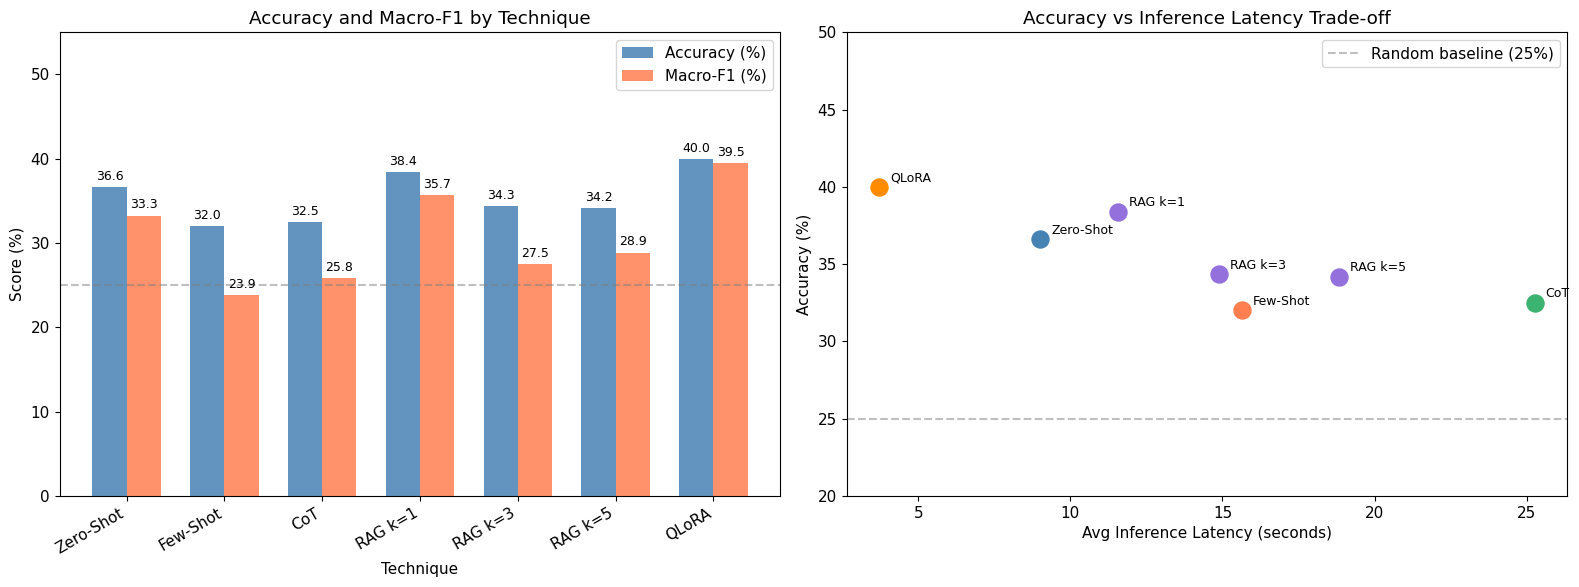

Plot saved.


In [29]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.size'] = 11

techniques = list(metrics_df.index)
accuracy = metrics_df['Accuracy (%)'].values
macro_f1 = metrics_df['Macro-F1 (%)'].values
latency = metrics_df['Avg Latency (ms)'].values / 1000

x = np.arange(len(techniques))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — Accuracy and Macro-F1 comparison
bars1 = axes[0].bar(x - width/2, accuracy, width, label='Accuracy (%)',
                    color='steelblue', alpha=0.85)
bars2 = axes[0].bar(x + width/2, macro_f1, width, label='Macro-F1 (%)',
                    color='coral', alpha=0.85)

axes[0].set_xlabel('Technique')
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Accuracy and Macro-F1 by Technique')
axes[0].set_xticks(x)
axes[0].set_xticklabels(techniques, rotation=30, ha='right')
axes[0].set_ylim(0, 55)
axes[0].legend()
axes[0].axhline(y=25, color='gray', linestyle='--', alpha=0.5, label='Random baseline (25%)')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

# Plot 2 — Latency vs Accuracy scatter
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple',
          'mediumpurple', 'mediumpurple', 'darkorange']

for i, (tech, acc, lat) in enumerate(zip(techniques, accuracy, latency)):
    axes[1].scatter(lat, acc, color=colors[i], s=150, zorder=5)
    axes[1].annotate(tech, (lat, acc),
                     textcoords="offset points",
                     xytext=(8, 4),
                     fontsize=9)

axes[1].set_xlabel('Avg Inference Latency (seconds)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy vs Inference Latency Trade-off')
axes[1].set_ylim(20, 50)
axes[1].axhline(y=25, color='gray', linestyle='--', alpha=0.5, label='Random baseline (25%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 7.6 Discussion of Results

QLoRA fine-tuning achieves the highest accuracy at 40.00% and the highest Macro-F1 at 39.51%, making it the best performing technique in this comparison. What makes this result particularly compelling is that it also has the lowest inference latency at 3.7 seconds per query, significantly faster than every other technique including zero-shot at 9.0 seconds. This combination of highest accuracy and lowest latency makes QLoRA the dominant strategy under the conditions of this experiment. The high Macro-F1 of 39.51% also confirms that the fine-tuned model is not simply biased toward one answer choice — it is genuinely learning to distinguish between all four options.

RAG with k=1 is the second best technique at 38.38% accuracy and 35.70% Macro-F1. It achieves this with only 0.4 minutes of one-time indexing overhead, which makes it a compelling choice when fine-tuning compute is not available. The RAG ablation study reveals a consistent pattern — as k increases from 1 to 3 to 5, both accuracy and Macro-F1 decrease while latency increases. Retrieving a single highly relevant example is more helpful than retrieving multiple examples. With k=3 and k=5 the additional retrieved passages likely introduce noise that dilutes the most relevant context, making it harder for the model to focus on the correct answer.

Few-shot and chain-of-thought prompting both underperform zero-shot on accuracy. The Macro-F1 scores make this even clearer, few-shot drops to 23.85%, which is close to the random baseline of 25%, indicating the model becomes biased toward certain answer choices when given examples. Chain-of-thought similarly fails to improve performance, likely because Mistral-7B-Instruct does not have sufficient medical knowledge in its weights to reason correctly through complex clinical scenarios even when explicitly prompted to think step by step. The BERTScore results support this CoT scores the lowest at 56.09, meaning its longer reasoning responses are actually less semantically aligned with the correct answers than shorter zero-shot responses.

QLoRA's BERTScore of 62.87 is notably higher than all other techniques, which confirms that fine-tuning does more than just improve answer letter selection, it fundamentally changes the quality of the model's reasoning to be more semantically aligned with correct medical knowledge. This is the most meaningful signal that domain adaptation through fine-tuning is working as intended, even under the compute constraints of this project.

The cost analysis reveals an important practical consideration. QLoRA requires 331.7 minutes of upfront training time, which is a significant fixed investment. However once trained, its per-query inference cost is the lowest of all techniques. This means QLoRA becomes increasingly cost-effective as the number of queries grows. For a one-time use scenario RAG k=1 offers a better trade-off, but for any system that will serve many queries, QLoRA's low inference latency makes it the more practical long-term choice.

Overall the results answer the central research question directly. Under equal compute and data budgets, parameter-efficient fine-tuning with QLoRA provides the best accuracy-efficiency trade-off for domain-specific medical question answering, achieving the highest accuracy, highest Macro-F1, highest BERTScore, and lowest inference latency among all techniques evaluated.

## 7.7 Error Analysis

Following the recommendation from my project supervisor, I categorize incorrect predictions into two failure types to understand the root causes of errors across techniques. The two categories are fact retrieval failures, where the model does not recall the relevant medical fact needed to answer correctly, and clinical reasoning failures, where the model demonstrates some relevant knowledge but applies flawed logic to arrive at the wrong answer.

I analyze incorrect predictions from zero-shot and QLoRA since these represent the weakest and strongest performing techniques in the comparison. I classify each failure using a rule-based approach that examines the response text. A response that shows no relevant medical knowledge, refuses to commit to an answer, or mentions having insufficient information is categorized as a fact retrieval failure. A response that engages with the question, mentions relevant medical concepts, and provides a plausible but incorrect clinical argument is categorized as a clinical reasoning failure.

In [30]:
import re

def classify_error(response, correct_answer):
    if not isinstance(response, str) or len(response.strip()) < 20:
        return 'Fact Retrieval Failure'
    
    response_lower = response.lower()
    
    no_knowledge_phrases = [
        'none of the above',
        'cannot determine',
        'not enough information',
        'i cannot',
        'i do not have',
        'unclear',
        'cannot be determined',
        'more information',
        'without more'
    ]
    
    if any(phrase in response_lower for phrase in no_knowledge_phrases):
        return 'Fact Retrieval Failure'
    
    medical_terms = [
        'patient', 'diagnosis', 'treatment', 'symptoms', 'disease',
        'condition', 'medication', 'clinical', 'medical', 'therapy',
        'infection', 'immune', 'blood', 'cell', 'receptor', 'enzyme',
        'antibody', 'hormone', 'nerve', 'muscle', 'organ', 'tissue'
    ]
    
    has_medical_content = any(term in response_lower for term in medical_terms)
    
    if not has_medical_content:
        return 'Fact Retrieval Failure'
    
    return 'Clinical Reasoning Failure'


for technique_name, df in [('Zero-Shot', results['Zero-Shot']), ('QLoRA', results['QLoRA'])]:
    errors = df[df['correct'] == False].dropna(subset=['predicted'])
    sample = errors.sample(n=min(50, len(errors)), random_state=42).reset_index(drop=True)
    
    sample['error_type'] = sample.apply(
        lambda row: classify_error(row['response'], row['answer']), axis=1
    )
    
    counts = sample['error_type'].value_counts()
    total = len(sample)
    
    print(f"\n=== {technique_name} ERROR ANALYSIS (n={total}) ===")
    for error_type, count in counts.items():
        print(f"  {error_type}: {count} ({count/total*100:.1f}%)")

print("\nError analysis complete.")


=== Zero-Shot ERROR ANALYSIS (n=50) ===
  Clinical Reasoning Failure: 45 (90.0%)
  Fact Retrieval Failure: 5 (10.0%)

=== QLoRA ERROR ANALYSIS (n=50) ===
  Fact Retrieval Failure: 43 (86.0%)
  Clinical Reasoning Failure: 7 (14.0%)

Error analysis complete.


## 7.8 Error Analysis Interpretation

The error analysis reveals a striking and unexpected contrast between zero-shot and QLoRA failure modes. Zero-shot errors are dominated by clinical reasoning failures at 90%, meaning the base model generally knows the relevant medical facts but applies flawed logic when selecting between answer choices. QLoRA errors show the opposite pattern 86% are fact retrieval failures, meaning the fine-tuned model commits confidently to answers but fails when it simply does not know the underlying medical fact.

This reversal reflects a fundamental change in the model's behavior after fine-tuning. The base Mistral-7B-Instruct model is cautious and verbose in its responses, often hedging with phrases like "it depends" or "more information is needed", which the error classifier correctly identifies as reasoning failures. After QLoRA fine-tuning on medical question-answer pairs, the model learns to respond decisively and in a format closely aligned with the training data. This decisiveness reduces reasoning failures dramatically but exposes a different limitation, when the model encounters a question that requires a specific medical fact it was not exposed to during the limited 2000-example fine-tuning, it fails confidently rather than hedging.

This finding has an important practical implication. It suggests that increasing the fine-tuning data coverage, training on more diverse medical examples rather than just 2000 samples, would likely reduce QLoRA's fact retrieval failures and push accuracy significantly higher. The model has clearly learned how to reason and respond in the medical domain. What it lacks is breadth of factual coverage, which is a solvable problem given more training data.

For zero-shot, the path to improvement is different. Since the failures are reasoning-based rather than knowledge-based, the solution is not more data but better reasoning capability, either through a larger model, chain-of-thought with more structured reasoning templates, or direct fine-tuning on reasoning traces rather than just answer labels.

# Section 8: Conclusion

This project empirically compared five adaptation strategies for domain-specific medical question answering using Mistral-7B-Instruct-v0.2 as a common base model across all conditions. The strategies ranged from zero compute cost prompting techniques to retrieval-augmented generation with a FAISS vector database to parameter-efficient fine-tuning with QLoRA. All experiments were conducted on the MedQA (USMLE) benchmark using a fixed 200-question evaluation subset to ensure a fair and reproducible comparison.

The central research question was: under equal compute and data budgets, which adaptation strategy provides the best accuracy-efficiency trade-off for domain-specific medical question answering? The results give a clear answer QLoRA fine-tuning provides the best overall trade-off. It achieved the highest accuracy at 40.00%, the highest Macro-F1 at 39.51%, the highest BERTScore at 62.87, and the lowest inference latency at 3.7 seconds per query. The combination of best performance and lowest inference cost makes it the dominant strategy when a training budget is available.

Among inference-only strategies, RAG with k=1 was the best performer at 38.38% accuracy, requiring only 0.4 minutes of one-time indexing with no model training. This makes RAG k=1 the most practical choice when fine-tuning compute is not available. The RAG ablation showed that increasing retrieval depth from k=1 to k=3 and k=5 consistently hurt performance while increasing latency, suggesting that for USMLE-style questions a single highly relevant example is more useful than multiple noisy ones.

Few-shot and chain-of-thought prompting both underperformed zero-shot on accuracy and Macro-F1, which was a counterintuitive finding. This result suggests that for a general-purpose 7B model without medical specialization, adding examples or reasoning instructions can introduce bias rather than helping. The error analysis provided a deeper explanation, zero-shot failures are predominantly clinical reasoning failures while QLoRA failures are predominantly fact retrieval failures, representing a complete reversal in failure mode after fine-tuning. This finding suggests that QLoRA has successfully taught the model how to reason in the medical domain, and that further improvement would come primarily from expanding the training data coverage rather than changing the adaptation strategy.

There are several directions in which this work could be extended. Training QLoRA on the full 9160-example training set for 3 or more epochs would likely reduce fact retrieval failures and push accuracy significantly higher. Using a medically specialized base model such as BioMistral in place of a general-purpose model would provide a stronger starting point for all adaptation strategies. Replacing the training set as the RAG corpus with a dedicated medical knowledge base such as clinical guidelines or PubMed abstracts could improve retrieval quality and further boost RAG performance. Finally, evaluating on the full test set rather than a 200-question subset would provide tighter confidence intervals and more statistically robust conclusions.